# Diamond Price Analysis & Prediction
### A Data Analysis & Machine Learning Project

**Dataset:** The classic *Diamonds* dataset (53,940 rows) containing prices and physical attributes of diamonds — carat, cut, color, clarity, and dimensions.

**Goals:**
1. Clean and explore the data
2. Engineer meaningful features
3. Visualize interesting patterns with Plotly
4. Train and compare regression models (Linear Regression, Random Forest, Gradient Boosting) to predict `price`
5. Extract insights about what actually drives diamond prices


In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

pd.set_option('display.max_columns', None)
np.random.seed(42)


In [29]:
import os
os.makedirs("data/raw", exist_ok=True)

df.to_csv("data/raw/diamonds.csv", index=False)

In [1]:
pip install pandas numpy seaborn scikit-learn plotly

Note: you may need to restart the kernel to use updated packages.


## 1. Load the Data

In [30]:
df = sns.load_dataset('diamonds')
df.to_csv("data/diamonds.csv", index=False)
print(df.shape)
df.head()


(53940, 10)


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [31]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [32]:
df.describe()


,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


## 2. Data Cleaning

Diamonds have physical dimensions `x`, `y`, `z` (length, width, depth in mm). A value of 0 is physically impossible (it would mean the diamond has no size), so these are treated as missing/invalid data. We also check for duplicate rows and impossible values in `carat` and `price`.


In [33]:
# Check for zero/invalid dimensions
print("Rows with zero dimensions:", ((df['x']==0) | (df['y']==0) | (df['z']==0)).sum())
print("Duplicate rows:", df.duplicated().sum())
print("Missing values:\n", df.isnull().sum())


Rows with zero dimensions: 20
Duplicate rows: 146
Missing values:
 carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64


In [34]:
# Drop rows with impossible (zero) physical dimensions
df_clean = df[(df['x'] > 0) & (df['y'] > 0) & (df['z'] > 0)].copy()

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

# Sanity-check depth: depth% should roughly equal 2*z / (x+y) * 100 -- flag extreme outliers instead of dropping blindly
df_clean = df_clean[(df_clean['depth'] > 40) & (df_clean['depth'] < 80)]
df_clean = df_clean[(df_clean['table'] > 40) & (df_clean['table'] < 90)]

# Remove extreme outliers in y and z (likely data entry errors, e.g. y=58.9 when carat is tiny)
df_clean = df_clean[(df_clean['y'] < 20) & (df_clean['z'] < 20)]

print(f"Original rows: {len(df)}, Cleaned rows: {len(df_clean)}, Removed: {len(df) - len(df_clean)}")
df_clean.reset_index(drop=True, inplace=True)
df_clean.head()


Original rows: 53940, Cleaned rows: 53771, Removed: 169


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## 3. Feature Engineering

We derive new features that better capture the physical and economic properties of each diamond:

- **volume**: approximate volume in mm³ (x × y × z)
- **density_proxy**: carat / volume — a proxy for how "dense" (well-cut/compact) the stone is
- **table_to_depth_ratio**: relationship between table and depth percentages
- **price_per_carat**: price normalized by carat (useful for EDA, not used as a model input to avoid leakage)
- **carat_bin**: categorical bucket of carat size
- **cut/color/clarity ranks**: ordinal-encoded versions of the quality categories, since they have a natural order


In [35]:
df_fe = df_clean.copy()

# Volume & density proxy
df_fe['volume'] = df_fe['x'] * df_fe['y'] * df_fe['z']
df_fe['density_proxy'] = df_fe['carat'] / df_fe['volume']

# Table-to-depth ratio
df_fe['table_to_depth_ratio'] = df_fe['table'] / df_fe['depth']

# Price per carat (for EDA only)
df_fe['price_per_carat'] = df_fe['price'] / df_fe['carat']

# Carat bins
df_fe['carat_bin'] = pd.cut(df_fe['carat'],
                             bins=[0, 0.5, 1, 1.5, 2, 5],
                             labels=['<0.5', '0.5-1', '1-1.5', '1.5-2', '2+'])

# Ordinal ranks (natural quality order, worst -> best)
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_order = ['J', 'I', 'H', 'G', 'F', 'E', 'D']  # J worst -> D best
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

df_fe['cut_rank'] = df_fe['cut'].astype(str).map({v: i for i, v in enumerate(cut_order)}).astype(int)
df_fe['color_rank'] = df_fe['color'].astype(str).map({v: i for i, v in enumerate(color_order)}).astype(int)
df_fe['clarity_rank'] = df_fe['clarity'].astype(str).map({v: i for i, v in enumerate(clarity_order)}).astype(int)

# Overall quality score (simple weighted sum)
df_fe['quality_score'] = df_fe['cut_rank'] + df_fe['color_rank'] + df_fe['clarity_rank']

df_fe.head()


,carat,cut,color,clarity,depth,table,price,x,y,z,volume,density_proxy,table_to_depth_ratio,price_per_carat,carat_bin,cut_rank,color_rank,clarity_rank,quality_score
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,38.202030,0.006021,0.894309,1417.391304,<0.5,4,5,1,10
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,34.505856,0.006086,1.020067,1552.380952,<0.5,3,5,2,10
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,38.076885,0.006040,1.142355,1421.739130,<0.5,1,5,4,10
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,46.724580,0.006207,0.929487,1151.724138,<0.5,3,1,3,7
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,51.917250,0.005971,0.916272,1080.645161,<0.5,1,0,1,2


## 4. Exploratory Visualizations (Plotly)

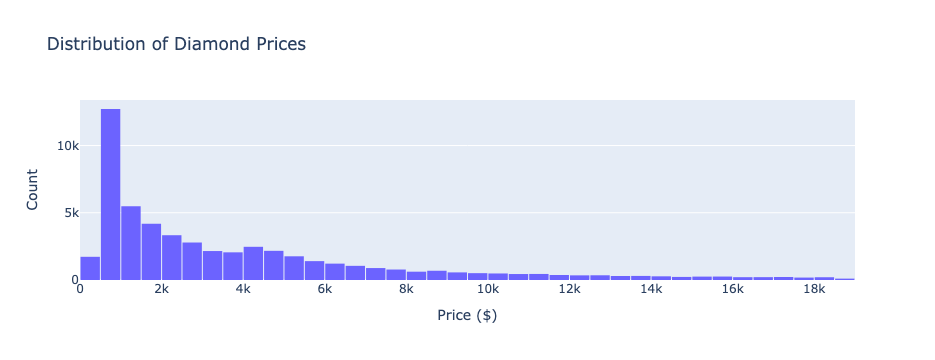

In [36]:
fig = px.histogram(df_fe, x='price', nbins=80, title='Distribution of Diamond Prices',
                    color_discrete_sequence=['#6C63FF'])
fig.update_layout(bargap=0.05, xaxis_title='Price ($)', yaxis_title='Count')
fig.show()


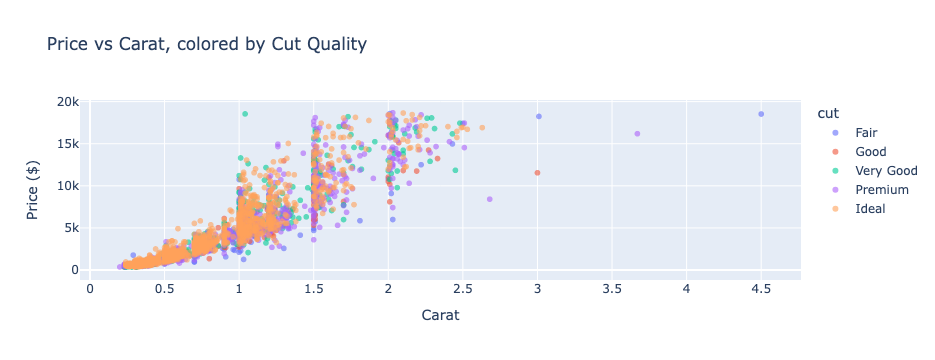

In [37]:
fig = px.scatter(df_fe.sample(4000, random_state=42), x='carat', y='price', color='cut',
                  title='Price vs Carat, colored by Cut Quality',
                  opacity=0.6, category_orders={'cut': cut_order})
fig.update_layout(xaxis_title='Carat', yaxis_title='Price ($)')
fig.show()


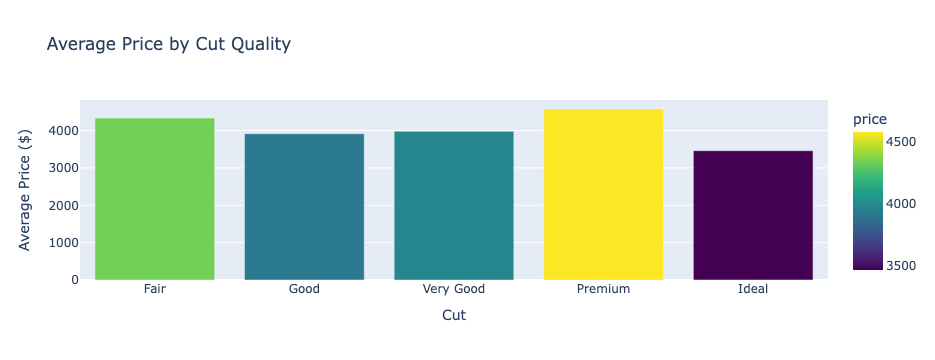

In [38]:
avg_price = df_fe.groupby('cut', observed=True)['price'].mean().reindex(cut_order).reset_index()
fig = px.bar(avg_price, x='cut', y='price', title='Average Price by Cut Quality',
             color='price', color_continuous_scale='Viridis')
fig.update_layout(xaxis_title='Cut', yaxis_title='Average Price ($)')
fig.show()


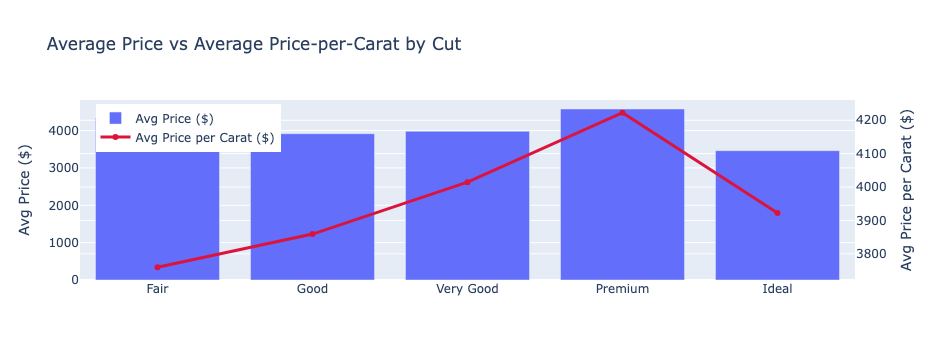

In [39]:
# Interesting finding: naive average price by cut is misleading because premium cuts
# tend to be paired with smaller carats. Compare price-per-carat instead.
ppc = df_fe.groupby('cut', observed=True)['price_per_carat'].mean().reindex(cut_order).reset_index()
fig = go.Figure()
fig.add_trace(go.Bar(x=avg_price['cut'], y=avg_price['price'], name='Avg Price ($)', yaxis='y1'))
fig.add_trace(go.Scatter(x=ppc['cut'], y=ppc['price_per_carat'], name='Avg Price per Carat ($)',
                          yaxis='y2', mode='lines+markers', line=dict(color='crimson', width=3)))
fig.update_layout(
    title='Average Price vs Average Price-per-Carat by Cut',
    yaxis=dict(title='Avg Price ($)'),
    yaxis2=dict(title='Avg Price per Carat ($)', overlaying='y', side='right'),
    legend=dict(x=0.02, y=0.98)
)
fig.show()


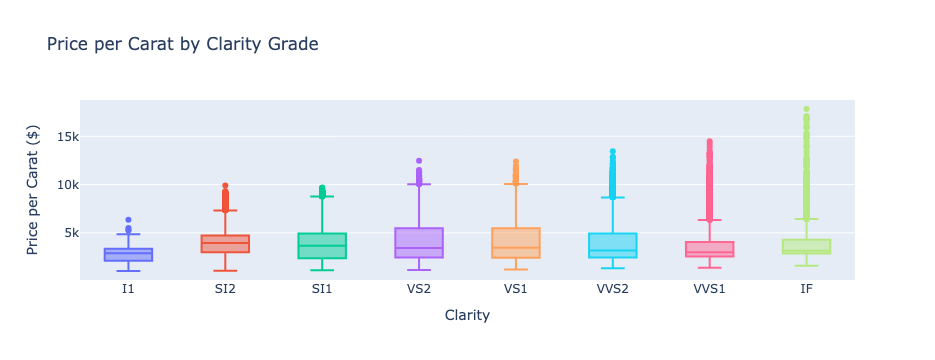

In [40]:
fig = px.box(df_fe, x='clarity', y='price_per_carat',
             category_orders={'clarity': clarity_order},
             title='Price per Carat by Clarity Grade', color='clarity')
fig.update_layout(showlegend=False, xaxis_title='Clarity', yaxis_title='Price per Carat ($)')
fig.show()


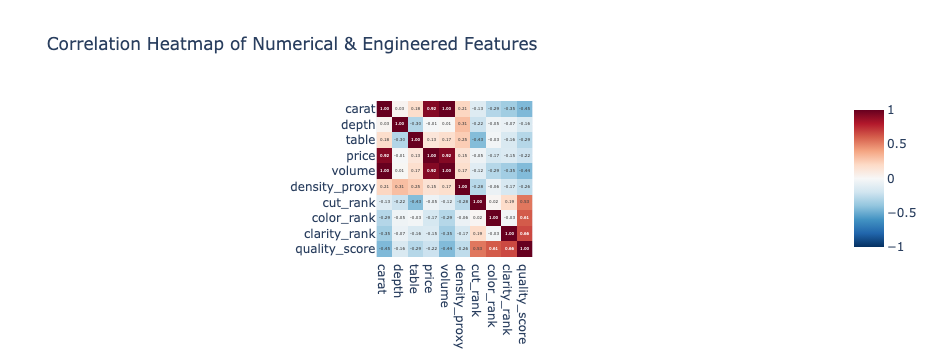

In [41]:
corr_cols = ['carat', 'depth', 'table', 'price', 'volume', 'density_proxy',
             'cut_rank', 'color_rank', 'clarity_rank', 'quality_score']
corr = df_fe[corr_cols].corr()
fig = px.imshow(corr, text_auto='.2f', color_continuous_scale='RdBu_r', zmin=-1, zmax=1,
                title='Correlation Heatmap of Numerical & Engineered Features')
fig.show()


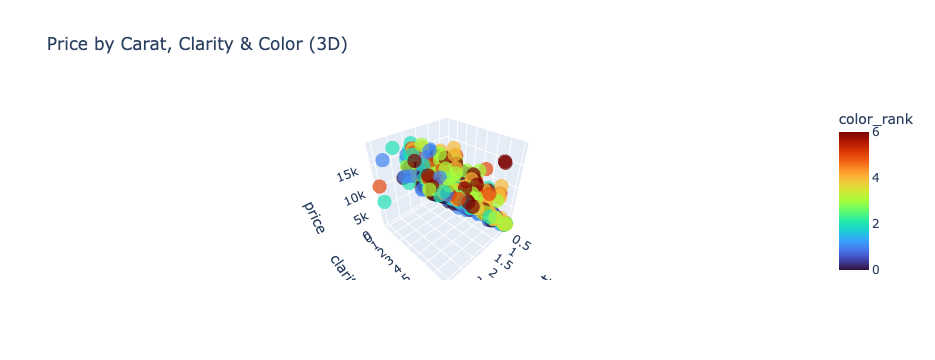

In [42]:
fig = px.scatter_3d(df_fe.sample(2000, random_state=1), x='carat', y='clarity_rank', z='price',
                     color='color_rank', title='Price by Carat, Clarity & Color (3D)',
                     color_continuous_scale='Turbo', opacity=0.7)
fig.show()


**Key EDA takeaway:** carat size dominates price, but it correlates strongly with `x`, `y`, `z`, and `volume` (all essentially describe "how big the stone is"). Cut quality shows a *counter-intuitive* pattern in raw average price (Fair-cut diamonds can look pricier on average) simply because buyers of large carat stones don't always choose Ideal cuts — but price-*per-carat* tells the true story: better cuts do command a premium once size is controlled for.


## 5. Model Preparation

We predict `price` using the physical/quality features (excluding leakage features like `price_per_carat`). Categorical columns are ordinal-encoded using their natural quality order; `carat_bin` is dropped since `carat` itself is already included.


In [43]:
feature_cols = ['carat', 'depth', 'table', 'x', 'y', 'z', 'volume', 'density_proxy',
                'table_to_depth_ratio', 'cut_rank', 'color_rank', 'clarity_rank', 'quality_score']
target_col = 'price'

X = df_fe[feature_cols]
y = df_fe[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)


(43016, 13) (10755, 13)


## 6. Model Training & Comparison

In [44]:
models = {
    'Linear Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    'Ridge Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0))
    ]),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42)
}

results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    predictions[name] = preds
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})

results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
results_df


,Model,MAE,RMSE,R2
0,Gradient Boosting,288.159369,537.860399,0.981430
1,Random Forest,280.517850,547.174462,0.980781
2,Linear Regression,782.666685,1186.763643,0.909592
3,Ridge Regression,782.960349,1186.770323,0.909591


In [45]:
fig = px.bar(results_df, x='Model', y='R2', color='Model', title='Model Comparison: R² Score',
             text_auto='.4f')
fig.update_layout(showlegend=False, yaxis_title='R² Score', yaxis_range=[0.85, 1.0])
fig.show()


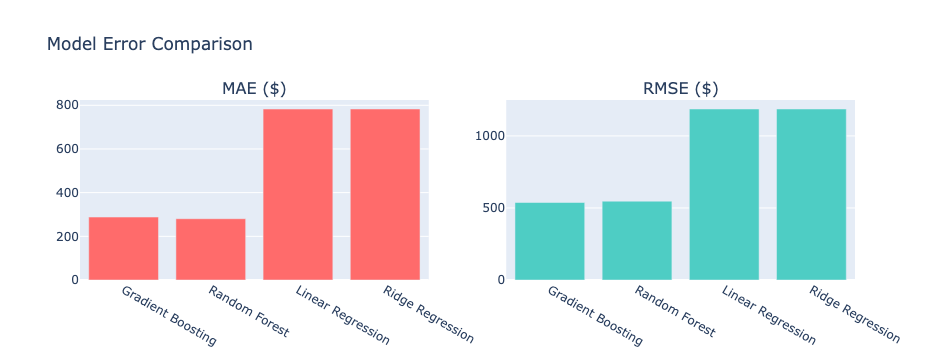

In [46]:
fig = make_subplots(rows=1, cols=2, subplot_titles=('MAE ($)', 'RMSE ($)'))
fig.add_trace(go.Bar(x=results_df['Model'], y=results_df['MAE'], marker_color='#FF6B6B'), row=1, col=1)
fig.add_trace(go.Bar(x=results_df['Model'], y=results_df['RMSE'], marker_color='#4ECDC4'), row=1, col=2)
fig.update_layout(title='Model Error Comparison', showlegend=False)
fig.show()


## 7. Best Model — Deeper Dive

Gradient Boosting / Random Forest typically outperform linear models here because diamond pricing is highly non-linear (e.g. price grows roughly exponentially with carat, and quality grades interact with size).


Best model: Gradient Boosting


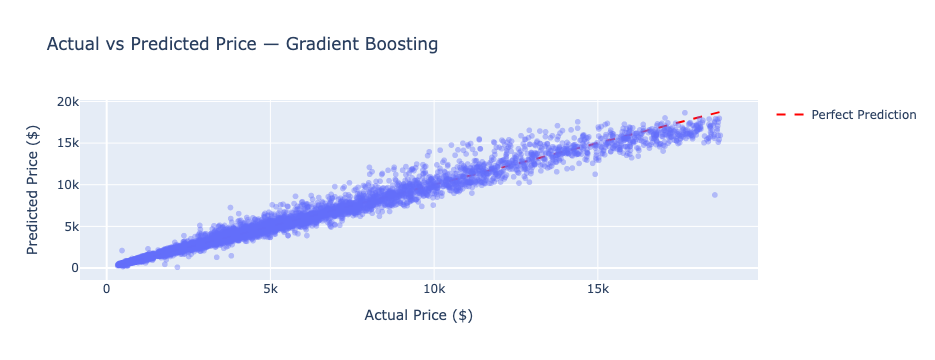

In [47]:
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
best_preds = predictions[best_model_name]
print(f"Best model: {best_model_name}")

fig = px.scatter(x=y_test, y=best_preds, opacity=0.4, labels={'x': 'Actual Price ($)', 'y': 'Predicted Price ($)'},
                  title=f'Actual vs Predicted Price — {best_model_name}')
fig.add_trace(go.Scatter(x=[y_test.min(), y_test.max()], y=[y_test.min(), y_test.max()],
                          mode='lines', name='Perfect Prediction', line=dict(color='red', dash='dash')))
fig.show()


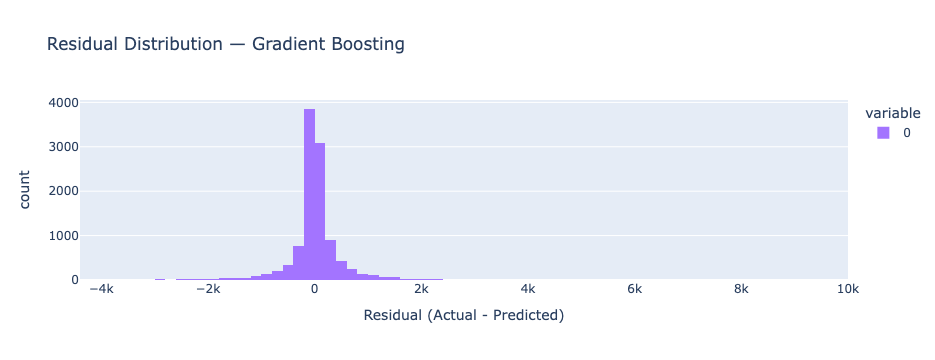

In [48]:
residuals = y_test.values - best_preds
fig = px.histogram(residuals, nbins=80, title=f'Residual Distribution — {best_model_name}',
                    labels={'value': 'Residual (Actual - Predicted)'}, color_discrete_sequence=['#A374FF'])
fig.show()


In [49]:
# Feature importance (only for tree-based models)
if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    fig = px.bar(importance_df, x='Importance', y='Feature', orientation='h',
                 title=f'Feature Importance — {best_model_name}', color='Importance',
                 color_continuous_scale='Plasma')
    fig.update_layout(yaxis={'categoryorder': 'total ascending'})
    fig.show()


## 8. Findings & Conclusions

1. **Carat is king** — carat (and the related size/volume features) is overwhelmingly the strongest predictor of price, consistent with how diamonds are actually priced in the trade.
2. **Cut quality is subtle** — looking at *raw* average price by cut is misleading, since larger stones aren't always given the best cuts. Once you normalize by price-per-carat, better cuts (Ideal, Premium) *do* command a real premium.
3. **Non-linear pricing** — tree-based ensembles (Random Forest / Gradient Boosting) clearly beat linear models, confirming that diamond price is not a simple linear function of its attributes — there are interaction effects (e.g., a poor cut hurts more on a large stone than a small one).
4. **Engineered features add value** — `volume` and `quality_score` rank among the more informative engineered features, showing that combining raw attributes can better represent the underlying "value" of a diamond than any single raw column.
5. **Diminishing residual bias** — the best model's residuals are roughly centered at zero with a slight tendency to underpredict very high-priced diamonds, suggesting rare, extremely high-quality stones command prices driven by factors not captured in this dataset (brand, certification, provenance).
